In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
cf = pd.read_csv(r"C:\Users\priya\Desktop\PyCh_Pro\Churn_Analysis_and_Modelling\data\raw\telco_churn.csv")

In [3]:
cf.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6196,2988-QRAJY,Male,0,No,No,69,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),110.05,7430.75,No
3579,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
66,8627-ZYGSZ,Male,0,Yes,No,47,Yes,Yes,Fiber optic,No,...,No,No,No,No,One year,Yes,Electronic check,78.90,3650.35,No
2706,7598-UAASY,Male,0,Yes,No,2,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Electronic check,76.40,151.8,Yes
441,5628-RKIFK,Female,1,No,No,49,Yes,Yes,Fiber optic,Yes,...,No,No,Yes,Yes,Month-to-month,No,Credit card (automatic),101.55,5070.4,No


In [4]:
cf.shape

(7043, 21)

In [5]:
cf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
cf.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1007,6993-OHLXR,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,No,Electronic check,68.95,119.75,Yes
3925,9938-ZREHM,Female,0,Yes,No,37,Yes,Yes,DSL,No,...,No,Yes,No,Yes,One year,No,Mailed check,72.10,2658.4,No
5690,0336-KXKFK,Male,0,No,No,72,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),61.20,4390.25,No
3529,2880-FPNAE,Male,1,Yes,No,2,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,74.20,140.1,No
4680,1986-PHGZF,Male,1,No,No,18,Yes,Yes,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),58.40,964.9,No


In [7]:
cf["gender"] = cf["gender"].astype("category")
cf["Partner"] = cf["Partner"].astype("category")
cf["Dependents"] = cf["Dependents"].astype("category")
cf["PhoneService"] = cf["PhoneService"].astype("category")
cf["MultipleLines"] = cf["MultipleLines"].astype("category")
cf["InternetService"] = cf["InternetService"].astype("category")
cf["OnlineSecurity"] = cf["OnlineSecurity"].astype("category")
cf["OnlineBackup"] = cf["OnlineBackup"].astype("category")
cf["DeviceProtection"] = cf["DeviceProtection"].astype("category")
cf["TechSupport"] = cf["TechSupport"].astype("category")
cf["StreamingTV"] = cf["StreamingTV"].astype("category")
cf["StreamingMovies"] = cf["StreamingMovies"].astype("category")
cf["Contract"] = cf["Contract"].astype("category")
cf["PaperlessBilling"] = cf["PaperlessBilling"].astype("category")
cf["PaymentMethod"] = cf["PaymentMethod"].astype("category")
cf["Churn"] = cf["Churn"].astype("category")

In [8]:
cf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   category
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   category
 4   Dependents        7043 non-null   category
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   category
 7   MultipleLines     7043 non-null   category
 8   InternetService   7043 non-null   category
 9   OnlineSecurity    7043 non-null   category
 10  OnlineBackup      7043 non-null   category
 11  DeviceProtection  7043 non-null   category
 12  TechSupport       7043 non-null   category
 13  StreamingTV       7043 non-null   category
 14  StreamingMovies   7043 non-null   category
 15  Contract          7043 non-null   category
 16  PaperlessBilling  7043 n

In [9]:
cf.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
cf.drop(columns = ["customerID"], inplace = True)

In [11]:
cf['TotalCharges'] = pd.to_numeric(cf['TotalCharges'], errors='coerce')

In [12]:
cf['TotalCharges'].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

In [13]:
cf['TotalCharges'].isnull().sum() # 11 null value appears

np.int64(11)

In [14]:
cf[cf['TotalCharges'].isnull()]["TotalCharges"]#these values were not numbers, but were something like " " or any other invalid number type

488    NaN
753    NaN
936    NaN
1082   NaN
1340   NaN
3331   NaN
3826   NaN
4380   NaN
5218   NaN
6670   NaN
6754   NaN
Name: TotalCharges, dtype: float64

In [15]:
cf["TotalCharges"] = cf["TotalCharges"].fillna(0)

In [16]:
cf["TotalCharges"].isnull().sum()

np.int64(0)

### Preprocessing Starts...

In [17]:
#train test split is not done because, it shuffles the data due to which time series data(assumption) simulation gets hindered
n = cf.shape[0]
train_end = int(0.70 * n)
test_end = int(0.85 * n)

In [18]:
X_train = cf.iloc[:train_end].drop(columns = ["Churn"])
y_train = cf.iloc[:train_end]["Churn"]
X_test = cf.iloc[train_end:test_end].drop(columns = ["Churn"])
y_test = cf.iloc[train_end:test_end]["Churn"]
X_stream = cf.iloc[test_end:].drop(columns = ["Churn"])
y_stream = cf.iloc[test_end:]["Churn"]

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train[["tenure", "MonthlyCharges", "TotalCharges"]])
scaled_num_train = scaler.transform(X_train[["tenure", "MonthlyCharges", "TotalCharges"]])
scaled_num_test = scaler.transform(X_test[["tenure", "MonthlyCharges", "TotalCharges"]])

In [20]:
scaler.mean_

array([  32.33711968,   64.85382353, 2278.54732252])

In [21]:
scaled_train_cf = pd.DataFrame(
    scaled_num_train,
    columns=["tenure", "MonthlyCharges", "TotalCharges"],
    index=X_train.index
)
X_train[["tenure", "MonthlyCharges", "TotalCharges"]] = scaled_train_cf

In [22]:
X_train[["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
0,-1.272240,-1.161465,-0.990497
1,0.067510,-0.262257,-0.171366
2,-1.231642,-0.365119,-0.956008
3,0.514094,-0.748360,-0.192839
4,-1.231642,0.193982,-0.936847
...,...,...,...
4925,1.285466,1.448227,2.027204
4926,1.204269,-0.156078,0.649549
4927,-0.094884,-1.519820,-0.722820
4928,-1.150445,-0.625590,-0.923655


In [23]:
X_train.index

RangeIndex(start=0, stop=4930, step=1)

In [24]:
scaled_test_cf = pd.DataFrame(
    scaled_num_test,
    columns =["tenure", "MonthlyCharges", "TotalCharges"],
    index = X_test.index
)
X_test[["tenure", "MonthlyCharges", "TotalCharges"]] = scaled_test_cf

In [25]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder

In [26]:
cf.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [27]:
cf.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4750,Male,0,No,No,9,No,No phone service,DSL,Yes,Yes,Yes,No,No,No,One year,No,Mailed check,39.55,373.00,No
5060,Female,0,No,No,18,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Electronic check,35.20,607.30,No
3561,Male,0,No,No,26,Yes,Yes,Fiber optic,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,80.50,2088.80,Yes
6497,Male,0,No,No,52,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,103.05,5364.80,No
4636,Male,0,Yes,Yes,44,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),20.00,860.85,No


In [28]:
internet_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

phone_cols = ["MultipleLines"]

binary_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "MultipleLines", "Partner", "Dependents",
    "PhoneService", "PaperlessBilling"
]


def clean_columns(df):
    df = df.copy()
    
    # convert to lowercase + strip spaces
    for col in binary_cols:
        df[col] = df[col].astype(str).str.strip().str.lower()
    
    # fix "no internet service"
    for col in internet_cols:
        df[col] = df[col].replace("no internet service", "no")
    
    # fix "no phone service"
    for col in phone_cols:
        df[col] = df[col].replace("no phone service", "no")
    
    return df

In [29]:
X_train = clean_columns(X_train)
X_test  = clean_columns(X_test)



mapping = {"no": 0, "yes": 1}

for col in binary_cols:
    X_train[col] = X_train[col].map(mapping).astype(int)
    X_test[col]  = X_test[col].map(mapping).astype(int)


print("NaN check after encoding:")
print(X_train[binary_cols].isna().sum())
print(X_test[binary_cols].isna().sum())

NaN check after encoding:
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
MultipleLines       0
Partner             0
Dependents          0
PhoneService        0
PaperlessBilling    0
dtype: int64
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
MultipleLines       0
Partner             0
Dependents          0
PhoneService        0
PaperlessBilling    0
dtype: int64


In [30]:
X_train.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
1470,Female,0,0,0,-0.988051,1,0,No,0,0,0,0,0,0,Month-to-month,0,Mailed check,-1.514843,-0.934557
390,Female,0,0,0,-0.216679,1,1,Fiber optic,0,0,0,0,1,1,Month-to-month,1,Bank transfer (automatic),1.020191,0.139500
3977,Male,0,1,0,1.244867,1,0,Fiber optic,1,1,1,1,1,1,Two year,1,Credit card (automatic),1.501317,1.950055
364,Male,0,0,0,-0.582066,1,0,Fiber optic,0,0,0,1,0,0,Month-to-month,1,Bank transfer (automatic),0.366524,-0.398850
4643,Male,0,0,0,-1.191043,1,1,DSL,0,0,0,1,1,0,Month-to-month,1,Mailed check,0.013146,-0.911190


In [31]:
ohe = OneHotEncoder(drop="first", sparse_output=False)

cols = ["InternetService", "PaymentMethod", "gender"]

ohe.fit(X_train[cols])

train_ohe = ohe.transform(X_train[cols])
test_ohe  = ohe.transform(X_test[cols])

new_cols = ohe.get_feature_names_out(cols)

train_ohe_df = pd.DataFrame(train_ohe, columns=new_cols, index=X_train.index)
test_ohe_df  = pd.DataFrame(test_ohe,  columns=new_cols, index=X_test.index)

X_train = X_train.drop(columns=cols)
X_test  = X_test.drop(columns=cols)

X_train[new_cols] = train_ohe_df
X_test[new_cols]  = test_ohe_df

In [32]:
X_train.iloc[:5,-7:]

,TotalCharges,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender_Male
0,-0.990497,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.171366,0.0,0.0,0.0,0.0,1.0,1.0
2,-0.956008,0.0,0.0,0.0,0.0,1.0,1.0
3,-0.192839,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.936847,1.0,0.0,0.0,1.0,0.0,0.0


In [33]:
oe_ct = OrdinalEncoder(categories = [["Month-to-month", "One year", "Two year"]])
oe_ct.fit(X_train[["Contract"]])

train_oe = oe_ct.transform(X_train[["Contract"]])
test_oe = oe_ct.transform(X_test[["Contract"]])

X_train["Contract"] = train_oe
X_test["Contract"]  = test_oe

In [34]:
y_train = y_train.map({'Yes': 1, 'No': 0}).astype(int)
y_test = y_test.map({"Yes" : 1, "No" : 0}).astype(int)

In [35]:
y_train

0       0
1       0
2       1
3       0
4       1
       ..
4925    0
4926    0
4927    0
4928    1
4929    0
Name: Churn, Length: 4930, dtype: int64

## Model Training Starts...

In [36]:
X_train.sample(5)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender_Male
1152,0,0,0,-1.028649,1,0,0,0,0,0,...,0.0,0,-0.331938,-0.840493,0.0,0.0,0.0,0.0,1.0,1.0
4223,0,0,0,-1.191043,1,0,0,0,0,0,...,0.0,1,0.180710,-0.906565,1.0,0.0,0.0,0.0,1.0,1.0
4853,0,0,0,0.838882,1,0,0,1,1,1,...,1.0,1,0.982033,1.217565,1.0,0.0,1.0,0.0,0.0,0.0
3263,0,1,1,0.798284,1,0,0,1,1,1,...,0.0,0,0.695017,0.949117,1.0,0.0,0.0,0.0,0.0,0.0
2098,0,0,0,-1.231642,1,1,1,0,0,0,...,0.0,0,0.859263,-0.926672,1.0,0.0,0.0,0.0,1.0,1.0


### Logistic Regression

In [39]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [40]:
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

In [41]:
print("y_pred: ", y_pred)
print(5 * "----------------")
print("y_prob :", y_prob) 

y_pred:  [1 1 0 ... 1 1 0]
--------------------------------------------------------------------------------
y_prob : [0.65522784 0.83815315 0.30085634 ... 0.7585472  0.87021277 0.09443617]


In [42]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)
print("\nROC-AUC Score:", roc_auc)

Accuracy: 0.7471590909090909

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.74      0.81       763
           1       0.53      0.77      0.63       293

    accuracy                           0.75      1056
   macro avg       0.71      0.75      0.72      1056
weighted avg       0.79      0.75      0.76      1056


Confusion Matrix:
 [[564 199]
 [ 68 225]]

ROC-AUC Score: 0.8354461238420282


The model is over predicting that people are churn, but the good part is ROC-AUC value is good and recall is good, which means the model is usable.

### Decision Tree Classifier

In [43]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [44]:
y_pred = dtc.predict(X_test)
y_prob = dtc.predict_proba(X_test)[:, 1]

print("y_pred: ", y_pred)
print(5 * "----------------")
print("y_prob :", y_prob) 

y_pred:  [0 1 0 ... 0 1 0]
--------------------------------------------------------------------------------
y_prob : [0. 1. 0. ... 0. 1. 0.]


In [45]:
importance = pd.Series(dtc.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)
importance

TotalCharges                             0.201031
MonthlyCharges                           0.192670
Contract                                 0.169716
tenure                                   0.125802
InternetService_Fiber optic              0.057049
gender_Male                              0.029008
PaymentMethod_Electronic check           0.024723
MultipleLines                            0.022061
PaperlessBilling                         0.021169
TechSupport                              0.018679
OnlineBackup                             0.017107
OnlineSecurity                           0.016458
Partner                                  0.015347
Dependents                               0.014414
SeniorCitizen                            0.012847
StreamingTV                              0.012222
PaymentMethod_Mailed check               0.011830
StreamingMovies                          0.009638
InternetService_No                       0.009100
DeviceProtection                         0.008856


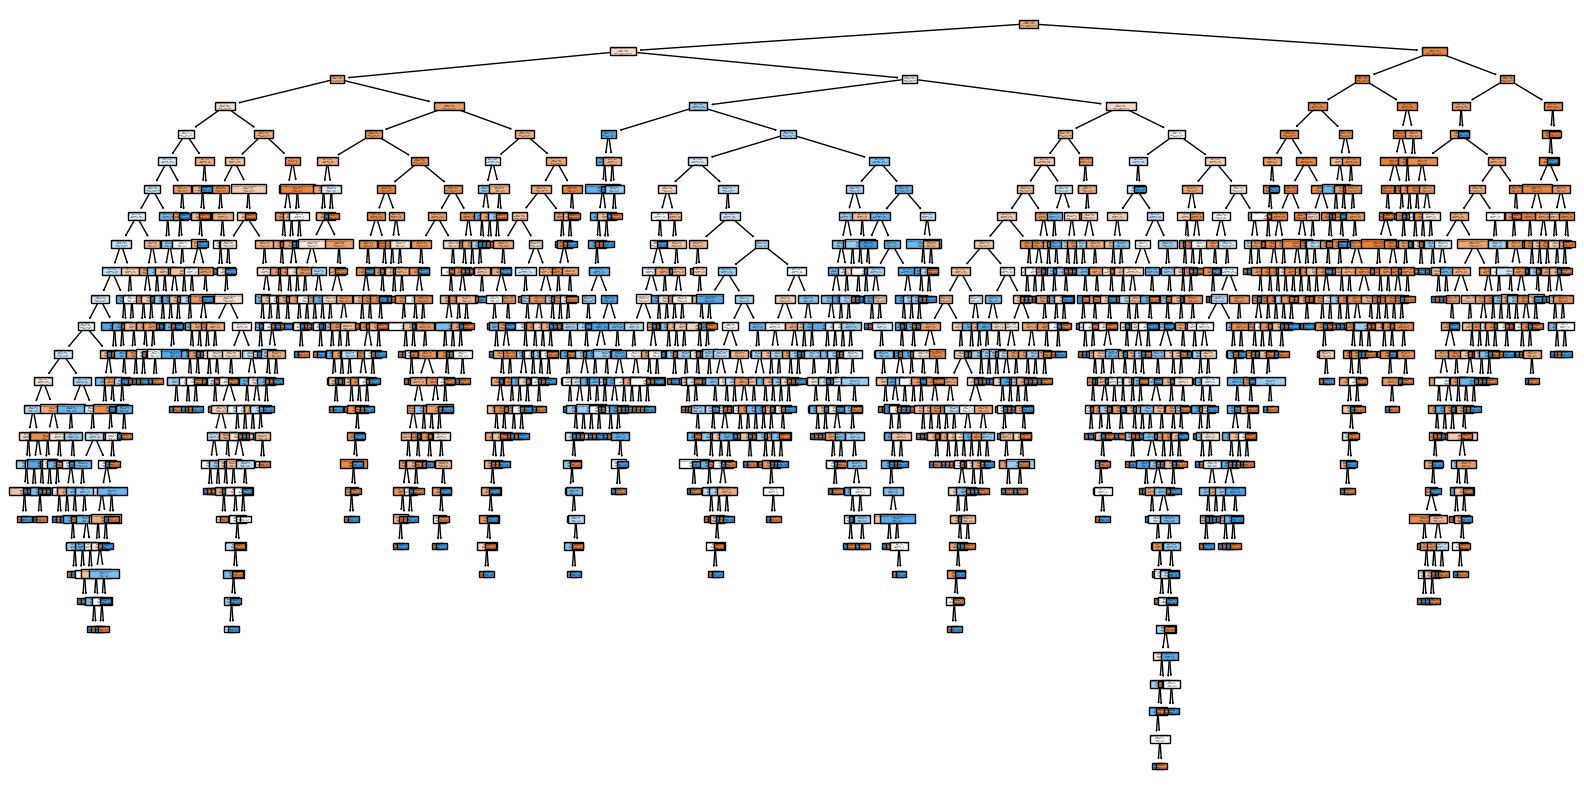

In [46]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dtc, feature_names=X_train.columns, class_names=["No", "Yes"], filled=True)
plt.show()

In [47]:
from sklearn.tree import export_graphviz
import graphviz
%matplotlib inline

dot_data = export_graphviz(
    dtc,
    out_file=None,
    feature_names=X_train.columns,
    class_names=["No", "Yes"],
    filled=True
)

graph = graphviz.Source(dot_data)
graph

In [75]:
graph.render("decision_tree", format="png", cleanup=True)

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.589748 to fit


'decision_tree.png'

In [76]:
graph.render("decision_tree", format="pdf", cleanup=True)

'decision_tree.pdf'

In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score



accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy:  0.7471590909090909
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       763
           1       0.55      0.51      0.53       293

    accuracy                           0.75      1056
   macro avg       0.68      0.67      0.68      1056
weighted avg       0.74      0.75      0.74      1056

ROC-AUC: 0.6758663261152537


In [49]:
from sklearn.metrics import precision_score, recall_score

y_pred = model.predict(X_test)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.5306603773584906
Recall: 0.7679180887372014


In [50]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

thresholds = np.arange(0.1, 0.9, 0.1)

for t in thresholds:
    y_pred = (y_prob > t).astype(int)
    
    p = precision_score(y_test, y_pred)
    r = recall_score(y_test, y_pred)
    
    print(f"Threshold: {t:.1f} | Precision: {p:.2f} | Recall: {r:.2f}")

Threshold: 0.1 | Precision: 0.55 | Recall: 0.52
Threshold: 0.2 | Precision: 0.55 | Recall: 0.52
Threshold: 0.3 | Precision: 0.55 | Recall: 0.52
Threshold: 0.4 | Precision: 0.55 | Recall: 0.52
Threshold: 0.5 | Precision: 0.55 | Recall: 0.51
Threshold: 0.6 | Precision: 0.55 | Recall: 0.51
Threshold: 0.7 | Precision: 0.55 | Recall: 0.51
Threshold: 0.8 | Precision: 0.55 | Recall: 0.51


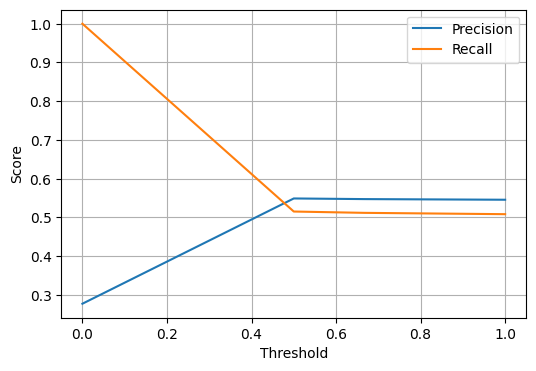

In [51]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()

In [52]:
from sklearn.metrics import f1_score
import numpy as np

best_t = 0
best_f1 = 0

for t in thresholds:
    y_pred = (y_prob > t).astype(int)
    f1 = f1_score(y_test, y_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best Threshold:", best_t)
print("Best F1:", best_f1)

Best Threshold: 0.0
Best F1: 0.5316901408450704


### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]



In [ ]:
y_pred

In [86]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
print("Random Forest\n")
print("Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Random Forest

Accuracy:  0.7897727272727273
              precision    recall  f1-score   support

          No       0.82      0.90      0.86       763
         Yes       0.66      0.49      0.57       293

    accuracy                           0.79      1056
   macro avg       0.74      0.70      0.71      1056
weighted avg       0.78      0.79      0.78      1056

ROC-AUC: 0.8292889125465761


### Fine tuning of rf

In [87]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="roc_auc",   # IMPORTANT
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [88]:
random_search.best_params_

{'n_estimators': 500,
 'min_samples_split': 5,
 'min_samples_leaf': 4,
 'max_features': 'sqrt',
 'max_depth': 7}

In [79]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=7,
    max_features = 'sqrt',
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

In [77]:
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [80]:
best_t = 0
best_f1 = 0

for t in thresholds:
    y_pred = (y_prob > t).astype(int)
    f1 = f1_score(y_test, y_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best Threshold:", best_t)
print("Best F1:", best_f1)

Best Threshold: 0.2244698534378678
Best F1: 0.9194630872483222


In [73]:
y_pred = (y_prob >= 0.49858).astype(int)

In [74]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
print("Random Forest\n")
print("Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Random Forest

Accuracy:  0.9990530303030303
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       632
           1       1.00      1.00      1.00       424

    accuracy                           1.00      1056
   macro avg       1.00      1.00      1.00      1056
weighted avg       1.00      1.00      1.00      1056

ROC-AUC: 1.0


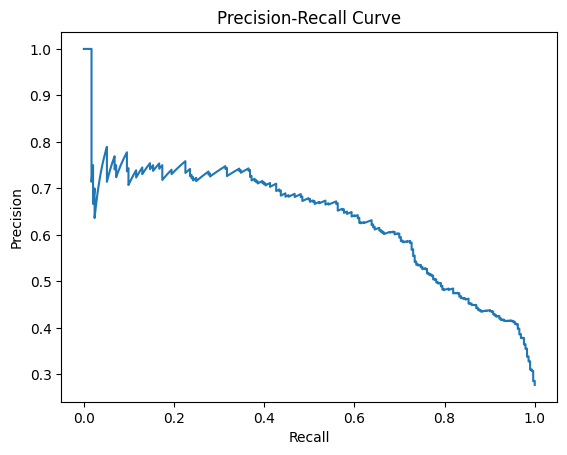

In [105]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

### XG Boost

In [115]:
y_train = y_train.map({"No": 0, "Yes": 1})
y_test = y_test.map({"No": 0, "Yes": 1})

In [116]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight= (len(y_train[y_train==0]) / len(y_train[y_train==1])),
    random_state=42
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [117]:
y_prob = xgb.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

C:\Users\priya\Desktop\PyCh_Pro\Churn_Analysis_and_Modelling\.venv\lib\site-packages\sklearn\externals\array_api_compat\numpy\_aliases.py:125: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype=dtype, copy=copy)


ValueError: Input y_true contains NaN.

In [ ]:
# 6. PRECISION-RECALL CURVE
# =========================

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# =========================
# 7. THRESHOLD TUNING
# =========================

print("\nThreshold Tuning:\n")

best_t = 0.5
best_score = 0

for t in np.arange(0.1, 0.9, 0.05):
    y_pred = (y_prob >= t).astype(int)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)

    print(f"Threshold: {t:.2f} | Recall: {rec:.3f} | Precision: {prec:.3f}")